In [39]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [7]:
df = pd.read_csv("drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [4]:
# print data types of columns
df.info()

# four columns are of object type and should be converted to numerical type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [46]:
# check for any missing values
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0
Drug_Num,0


Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


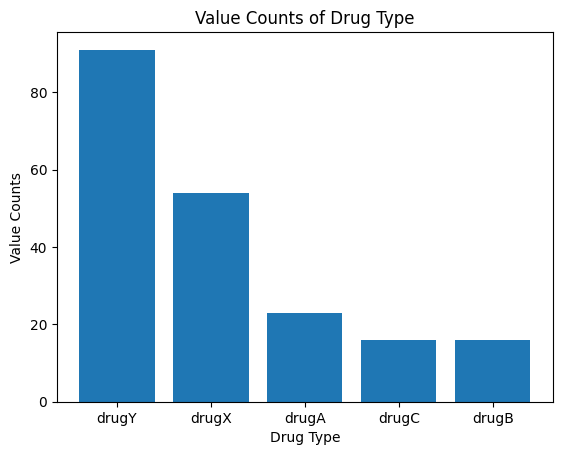

In [16]:
# get the count of values of dufferent drug types and plot them
drug_value_counts = df['Drug'].value_counts()
#print(type(drug_value_counts.iloc[0]))
print(drug_value_counts)
plt.bar(drug_value_counts.index, drug_value_counts.values)
plt.xlabel('Drug Type')
plt.ylabel('Value Counts')
plt.title('Value Counts of Drug Type')
plt.show()


In [9]:
# label encoder
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['BP'] = label_encoder.fit_transform(df['BP'])
df['Cholesterol'] = label_encoder.fit_transform(df['Cholesterol'])
df.head()

# BP 0 => High, 1=> Low, 2 => Normal
# Cholestrol 0=> High, 1=> Low
# Sex 0=> F, 1=> M

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


In [10]:
# convert target column values to numerical data type
custom_map = {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY':4}
df['Drug_Num'] = df['Drug'].map(custom_map)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_Num
0,23,0,0,0,25.355,drugY,4
1,47,1,1,0,13.093,drugC,2
2,47,1,1,0,10.114,drugC,2
3,28,0,2,0,7.798,drugX,3
4,61,0,1,0,18.043,drugY,4


In [55]:
# correlation with targe variable
df.drop(columns=['Drug']).corr()['Drug_Num']

,Drug_Num
Age,-0.004828
Sex,-0.098573
BP,0.372868
Cholesterol,0.055629
Na_to_K,0.589120
Drug_Num,1.000000


In [19]:
# get the features and target variable
X = df.drop(['Drug', 'Drug_Num'], axis=1)
y= df['Drug_Num']

In [56]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)
print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (140, 5)
X test shape: (60, 5)
y train shape: (140,)
y test shape: (60,)


In [57]:
tree_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=4)
tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [58]:
y_predict = tree_classifier.predict(X_test)
print(y_predict)

[4 1 3 0 4 4 0 4 4 3 3 3 3 4 2 4 4 0 4 0 4 0 4 3 3 4 1 4 3 4 4 2 2 4 4 4 4
 0 4 3 0 4 4 3 4 3 4 0 4 3 1 4 3 3 4 1 3 4 1 4]


In [59]:
# get the model accuracy
model_accuracy = accuracy_score(y_test, y_predict)
print("Accuracy of the model: ", model_accuracy)

Accuracy of the model:  0.9833333333333333


[Text(0.625, 0.9, 'x[4] <= 14.627\nentropy = 1.981\nsamples = 140\nvalue = [15, 11, 13, 38, 63]'),
 Text(0.5, 0.7, 'x[2] <= 0.5\nentropy = 1.797\nsamples = 77\nvalue = [15, 11, 13, 38, 0]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[0] <= 50.5\nentropy = 0.983\nsamples = 26\nvalue = [15.0, 11.0, 0.0, 0.0, 0.0]'),
 Text(0.125, 0.3, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0, 0, 0, 0]'),
 Text(0.375, 0.3, 'entropy = 0.0\nsamples = 11\nvalue = [0, 11, 0, 0, 0]'),
 Text(0.75, 0.5, 'x[3] <= 0.5\nentropy = 0.819\nsamples = 51\nvalue = [0, 0, 13, 38, 0]'),
 Text(0.625, 0.3, 'x[2] <= 1.5\nentropy = 0.988\nsamples = 23\nvalue = [0.0, 0.0, 13.0, 10.0, 0.0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 13\nvalue = [0, 0, 13, 0, 0]'),
 Text(0.75, 0.1, 'entropy = 0.0\nsamples = 10\nvalue = [0, 0, 0, 10, 0]'),
 Text(0.875, 0.3, 'entropy = 0.0\nsamples = 28\nvalue = [0, 0, 0, 28, 0]'),
 Text(0.75, 0.7, 'entropy = 0.0\nsamples = 63\nvalue = [0, 0, 0, 0, 63]'),
 Text(0.6875, 0.8, '  False')]

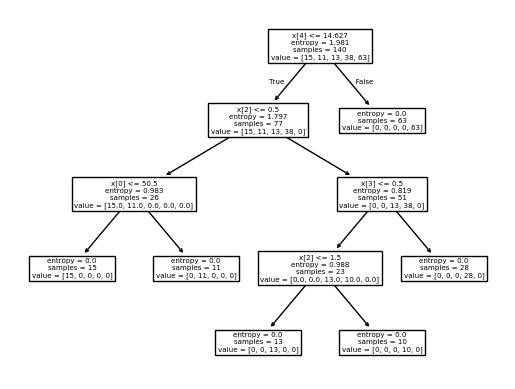

In [60]:
plot_tree(tree_classifier)
# we can infer that the model uses Na_to_K values > 14.627 as the criteria for drugY